In [1]:
import os

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import generate_areas as ga
from fringe_class import Fringe, FringeList
%load_ext autoreload
%autoreload 2

In [2]:
dir_path = 'drop-211025-2'

img_paths = [dir_path + '/'+ f for f in os.listdir(dir_path) if f.endswith('.jpg')]
img_paths.sort()

In [3]:
select = ga.Select(img_paths[3])
roi_max = select.select_roi()
roi_min = select.select_roi()

In [13]:
fringe_collection = []

for path in img_paths:
    select = ga.SelectRNGArea(path, roi_max = roi_max, roi_min = roi_min, num=50)
    select.get_random_rois()
    fringe_list = select.extract()
    fringe_collection.append(fringe_list)

/home/annamogo/PyProject/DiplomaLISF/venv/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  func(*args, **kwargs)
/home/annamogo/PyProject/DiplomaLISF/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


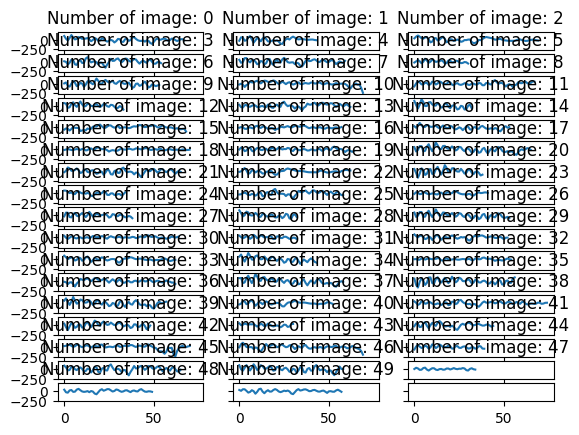

In [69]:
fringe_collection[1].plot()

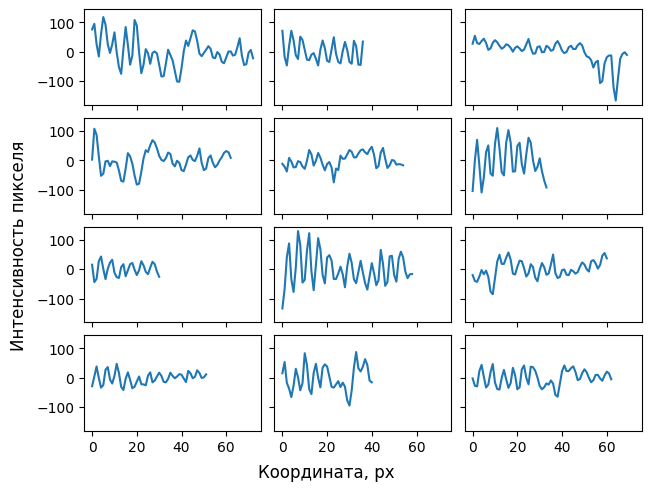

In [6]:
path_demo = img_paths[2]
num = 12

select = ga.SelectRNGArea(path_demo, roi_max = roi_max, roi_min = roi_min, num=num)
select.get_random_rois()
fringe_demo = select.extract()

fig, ax = plt.subplots(4,3, layout='constrained', sharex=True, sharey=True)

for i in range(num):
    ax[i//3][i%3].plot(fringe_demo.fringe_list[i].sig)

fig.supxlabel('Координата, px')
fig.supylabel('Интенсивность пикселя')

fig.savefig('rng_signals.jpg')
plt.show()
    
    



## Filter out the lowest frequencies

In [72]:
collection_low_ftl = []

for fringe_list in fringe_collection:
    fringe_list_new = fringe_list.filter_low_frq(inplace=False, nl=2)
    collection_low_ftl.append(fringe_list_new)

print(collection_low_ftl[0].list_len)

50


## Using phase unwraping method

In [14]:
frq_collection = []

for lines in collection_low_ftl:
    num_peaks = lines.count_peaks_of_autocorr()
    num = [i-1 for i in num_peaks]
    lines.filter_low_frq(nl=num)
    lines_Wn = lines.filter_notch_Wn(border=4, updateWn=True, rel_h=0.5, nperseg_c=1, inplace=False)
    frqs = lines_Wn.get_frq(prefilter=False)
    frq_collection.append(frqs)

In [15]:
means = [np.mean(frq) for frq in frq_collection]
stds = [np.std(frq) for frq in frq_collection]

means_f = [f"{m:.4f}" for m in means]
stds_f = [f"{s:.4f}" for s in stds]
print(means_f)
print(stds_f)

['1.6062', '1.4625', '1.3528', '1.2959', '1.2312', '1.1513', '1.1317', '1.0657', '1.0405', '1.0146', '0.9422', '0.8930', '0.8879', '0.8215']
['0.1698', '0.0390', '0.0653', '0.0381', '0.0531', '0.0151', '0.1437', '0.0561', '0.1155', '0.2132', '0.0891', '0.0748', '0.1637', '0.0160']


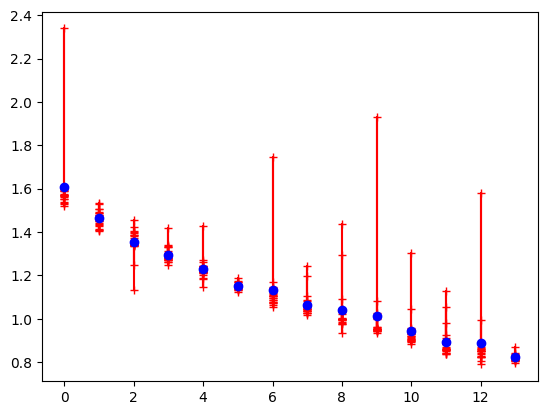

In [43]:
num = len(frq_collection)

plt.figure()

for i, frqs in enumerate(frq_collection):
    plt.plot([i]*len(frqs),frqs, color='red', marker='+')
    plt.plot(i, np.mean(frqs), color='blue', marker='o')

plt.show()

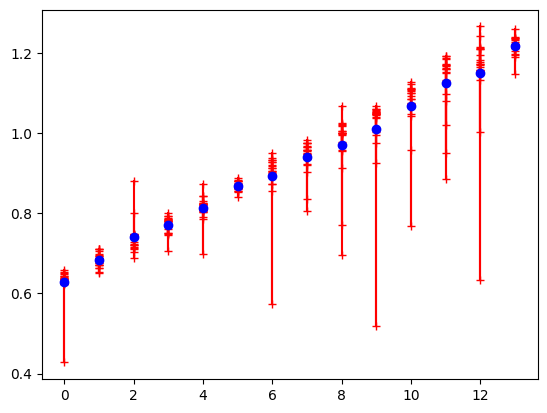

In [18]:
plt.figure()

for i, frqs in enumerate(frq_collection):
    T = [1/f for f in frqs]
    plt.plot([i]*len(frqs),T, color='red', marker = '+')
    plt.plot(i, np.mean(T), color='blue', marker='o')

plt.show()

## Using interpolation
### As initial guess for frequency we take the frequency, acquired by "unwraping" method

In [80]:
frq_est = [[f.count_peaks_of_autocorr()*2*np.pi/f.sig_len for f in fringe_list.fringe_list] for fringe_list in collection_low_ftl]

In [81]:
frq_cos_collection = []

for lines, frq in zip(collection_low_ftl,frq_est):

    frqs_cos = lines.get_frq_cos(init_guess_w=frq)
    frq_cos_collection.append(frqs_cos)

In [91]:
means_c = [np.mean(frq) for frq in frq_cos_collection]
stds_c = [np.std(frq) for frq in frq_cos_collection]

meansc_f = [f"{m:.4f}" for m in means_c]
stdsc_f = [f"{s:.4f}" for s in stds_c]
print(meansc_f)
print(stdsc_f)

['1.4011', '1.3351', '1.2529', '1.2033', '1.1590', '1.0794', '1.0252', '0.9882', '0.9506', '0.9323', '0.8556', '0.8446', '0.8129', '0.7828']
['0.2028', '0.1164', '0.1699', '0.1144', '0.0822', '0.1126', '0.1094', '0.0827', '0.0905', '0.0600', '0.0815', '0.0808', '0.0846', '0.0578']


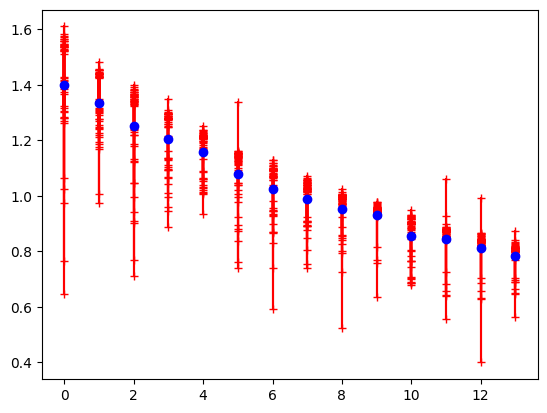

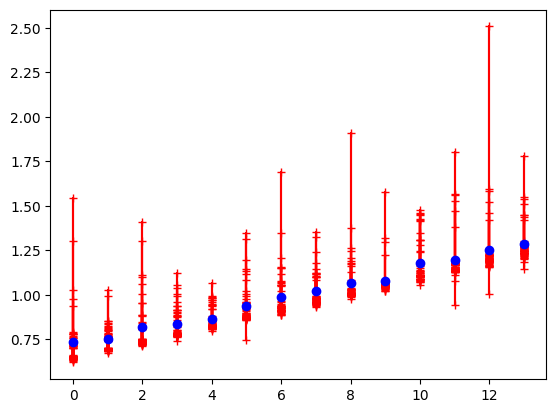

In [83]:
plt.figure()

for i, frqs in enumerate(frq_cos_collection):
    plt.plot([i]*len(frqs),frqs, color='red', marker='+')
    plt.plot(i, np.mean(frqs), color='blue', marker='o')

plt.show()

plt.figure()

for i, frqs in enumerate(frq_cos_collection):
    T = [1/f for f in frqs]
    plt.plot([i]*len(frqs),T, color='red', marker = '+')
    plt.plot(i, np.mean(T), color='blue', marker='o')

plt.show()

## create demo graph for both methods

In [84]:
frqs_max = [max(f) - np.mean(f) for f in frq_collection]
frqs_min = [np.mean(f) - min(f) for f in frq_collection]

frqs_c_max = [max(f) - np.mean(f) for f in frq_cos_collection]
frqs_c_min = [np.mean(f) - min(f) for f in frq_cos_collection]

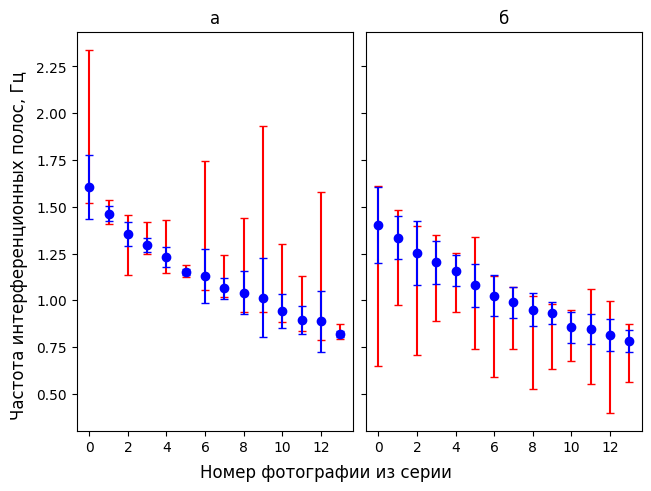

In [89]:
num = len(frq_collection)

x = np.arange(num)

fig, (ax1, ax2) = plt.subplots(1, 2, layout='constrained', sharex=True, sharey=True)

ax1.errorbar(x, means, yerr=[frqs_min, frqs_max], fmt='+', color='red', capsize=3)
ax1.errorbar(x, means, yerr=stds, fmt='o', color='blue', capsize=3)
ax1.set_title('а')
ax1.set_xticks([0, 2, 4, 6, 8, 10, 12]) 

ax2.errorbar(x, means_c, yerr=[frqs_c_min, frqs_c_max], fmt='+', color='red', capsize=3)
ax2.errorbar(x, means_c, yerr=stds_c, fmt='o', color='blue', capsize=3)
ax2.set_title('б')

fig.supxlabel('Номер фотографии из серии')
fig.supylabel('Частота интерференционных полос, Гц')

fig.savefig('method_error_comparison.jpg')

plt.show()

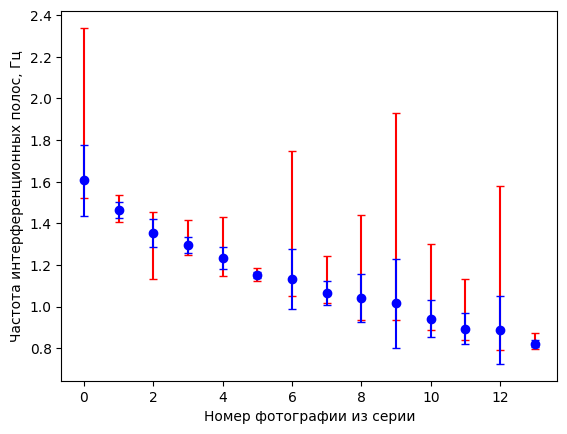

In [54]:
num = len(frq_collection)

x = np.arange(num)

plt.figure()

plt.errorbar(x, means, yerr=[frqs_min, frqs_max], fmt='+', color='red', capsize=3)
plt.errorbar(x, means, yerr=stds, fmt='o', color='blue', capsize=3)
plt.xlabel('Номер фотографии из серии')
plt.ylabel('Частота интерференционных полос, Гц')

plt.show()

## Generated data
### Generate some samples with additive Gaussian noise added to then and
### see how cosinus interpolation will predict the frequrncy of initial signal
### depending on the dispertion in the noise function

In [1]:
# by tryal and eror it was established, that when slp > 0.1 the intencity of lower frequences is too great
def noised_rng_sig(sig, mean_0, disp_0, slp_0, slp_dsp):
    L = len(sig)
    x = np.arange(L)
    A = max(abs(sig))
    mean = np.random.normal(mean_0, 0.5*A, 1)
    disp = 0
    while disp == 0:
        disp = np.random.normal(disp_0, 0.5*disp_0, 1)
    slp = np.random.normal(slp_0, slp_dsp, 1)
    x_0 = -L/2*slp

    white_noise = np.random.normal(mean, disp, L)
    trend = x*slp + x_0

    sig_out = sig + white_noise+trend
    return sig_out, mean, disp, slp

def noised_sig(sig, mean, disp, slp):
    L = len(sig)
    x = np.arange(L)
    x_0 = -L/2*slp

    white_noise = np.random.normal(mean, disp, L)
    trend = x*slp + x_0

    sig_out = sig + white_noise+trend
    return sig_out

In [4]:
# here we define parameters of generetes signal
T_0 = 5 # period of signal in pixels
f_0 = 2*np.pi/T_0
L = 50 # signal length
A = 1 # signal's amplitude

x = np.arange(L)
sig_0 = A*np.cos(f_0*x)

Optimal parameters not found: Number of calls to function has reached maxfev = 3000.
can not give frequency
Optimal parameters not found: Number of calls to function has reached maxfev = 3000.
can not give frequency
Optimal parameters not found: Number of calls to function has reached maxfev = 3000.
can not give frequency
N = 1; disp = 0.1; average frequency = 0.03232898394179193; average difference from target: 1.2244756375120436

Optimal parameters not found: Number of calls to function has reached maxfev = 3000.
can not give frequency
Optimal parameters not found: Number of calls to function has reached maxfev = 3000.
can not give frequency
Optimal parameters not found: Number of calls to function has reached maxfev = 3000.
can not give frequency
Optimal parameters not found: Number of calls to function has reached maxfev = 3000.
can not give frequency
Optimal parameters not found: Number of calls to function has reached maxfev = 3000.
can not give frequency
Optimal parameters not f

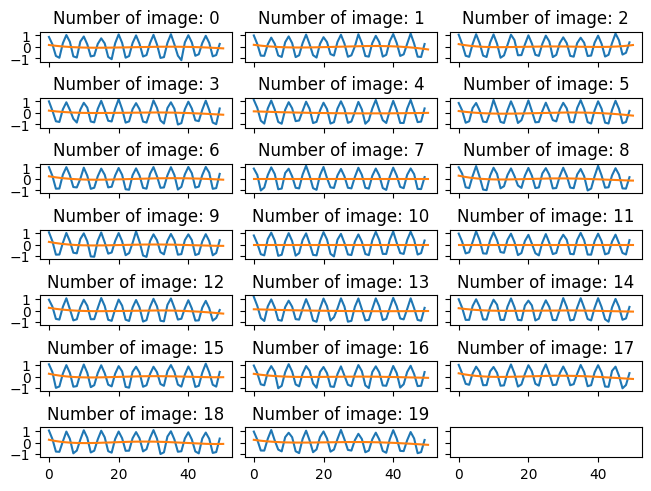

In [17]:
disp_list = np.linspace(start=0,stop=A, num=11)[1:]
slp = 0

mean = 0
N = 20

noised_sigs = []
frq = []
diff = []
i=1
for disp in disp_list:
    noised_batch = FringeList()
    for _ in range(N):
        sig = noised_sig(sig_0, mean=mean, disp=disp, slp=slp)
        noised = Fringe(signal=sig, fs=1)
        noised_batch.append(noised)


    #print(len(noised_batch.fringe_list))
    noised_batch.get_frq_cos()

    frq_arr = np.asarray(noised_batch.frq_cos_list)
    diff_arr = frq_arr - 0.4*np.pi

    frq_val = np.mean(frq_arr)
    diff_val = np.sqrt(np.mean(diff_arr**2))

    frq.append(frq_val)
    diff.append(diff_val)

    if i == 1:
        noised_batch.plot(show_cos=True)

    print(f"N = {i}; disp = {disp}; average frequency = {frq_val}; average difference from target: {diff_val}\n")
    i+=1

In [ ]:
mean = 0
N = 50

diff = []
slp_list = [0]
i = 1
for disp in disp_list:
    for slp in slp_list:
        
        noised_sigs = [noised_sig(sig_0, mean=mean, disp=disp, slp=slp) for _ in range(N)]
        ph_vel_hn = san.plot_flt_res(noised_sigs, fs=1, rel_h=0.5, nperseg_c=1)
        
        diff_arr = np.asarray(ph_vel_hn[0]) - 0.4*np.pi
        diff_val = np.sqrt(np.mean(diff_arr**2))
        diff.append(diff_val)
        
    print(f"N = {i}; disp = {disp}; slp = {slp}; average difference from target: {diff_val}\n")
    i+=1
    
        

In [ ]:
plt.semilogy(disp_list, diff, 'o')
plt.show()

print("disp: diff")
for x, y in zip(disp_list, diff):
    print(f"{x:.2f}:{y:.5f}\n")